# Data Structures

### Imports

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import random

from trees.bst import BinarySearchTree
from trees.optimal_bst import build_optimal_bst
from trees.splay_tree import SplayTree

from workloads.uniform import generate_random_requests
from workloads.hot_set import generate_hotset_requests
from workloads.temporal_locality import generate_temporal_requests

### Functions

In [2]:
def request_frequencies(n, requests):
    frequencies = [0 for _ in range(n)]

    for request in requests:
        frequencies[request] += 1
    
    return frequencies

def test_trees(n, requests, verbose=True):
    BST_search_cost = []
    opt_BST_search_cost = []
    ST_search_cost = []
    ST_rotations = []

    frequencies = request_frequencies(n, requests)
    opt_BST = build_optimal_bst(range(n), frequencies)
    BST = BinarySearchTree()
    ST = SplayTree()
    
    keys = list(range(n))
    random.shuffle(keys)    

    for key in keys:
        BST.insert(key)
        ST.insert(key)

    for request in requests:
        BST.search(request)
        opt_BST.search(request)
        ST.search(request)

        BST_search_cost.append(BST.search_cost)
        opt_BST_search_cost.append(opt_BST.search_cost)
        ST_search_cost.append(ST.search_cost)
        ST_rotations.append(ST.rotations)

    if verbose:
        print("Binary Search Tree Search Cost: ", BST_search_cost[-1])
        print("Optimal Binary Search Tree Search Cost:", opt_BST_search_cost[-1])
        print("Splay Tree Search Cost: ", ST_search_cost[-1])
        print("Splay Tree Rotation Count: ", ST_rotations[-1])

    return BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations


def plot_test(BST_search_cost,
              opt_BST_search_cost,
              ST_search_cost,
              ST_rotations,
              logarithmic=False):

    plt.figure()
    plt.plot(BST_search_cost, label="BST Search Cost")
    plt.plot(opt_BST_search_cost, label="Opt BST Search Cost")
    plt.plot(ST_search_cost, label="Splay Tree Search Cost")
    plt.plot(ST_rotations, label="Splay Tree Rotations")

    if logarithmic:
        plt.yscale("log")
        plt.xscale("log")

    plt.legend()
    plt.xlabel("Query Index")
    plt.ylabel("Count")
    plt.show()

### Uniform Distribution

Binary Search Tree Search Cost:  72508
Optimal Binary Search Tree Search Cost: 57328
Splay Tree Search Cost:  76620
Splay Tree Rotation Count:  66620


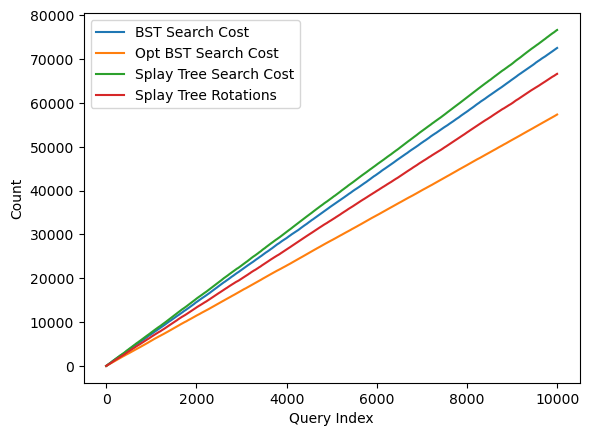

In [3]:
requests = generate_random_requests(100, 10000, 1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests)
plot_test(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

### Hot Set

**hot_fraction = 0.5** \
**hot_probability = 0.9**

Binary Search Tree Search Cost:  66424
Optimal Binary Search Tree Search Cost: 49314
Splay Tree Search Cost:  66698
Splay Tree Rotation Count:  56698


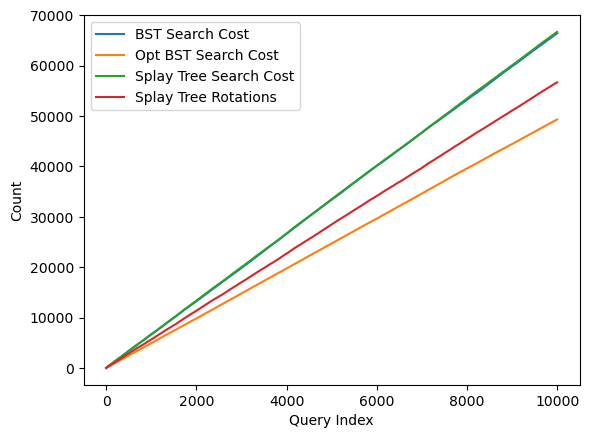

In [4]:
requests = generate_hotset_requests(100, 10000, 0.5, 0.9, 1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests)
plot_test(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

**hot_fraction = 0.8** \
**hot_probability = 0.9**

Binary Search Tree Search Cost:  77189
Optimal Binary Search Tree Search Cost: 54695
Splay Tree Search Cost:  73497
Splay Tree Rotation Count:  63497


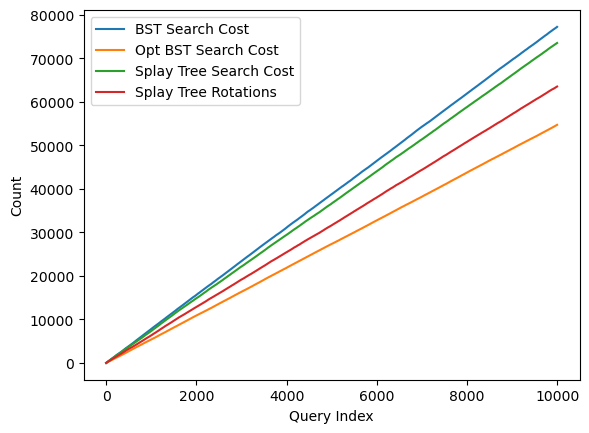

In [5]:
requests = generate_hotset_requests(100, 10000, 0.8, 0.9, 1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests)
plot_test(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

### Temporal Locality

**p_repeat = 0.5**

Binary Search Tree Search Cost:  69572
Optimal Binary Search Tree Search Cost: 56645
Splay Tree Search Cost:  43318
Splay Tree Rotation Count:  33318


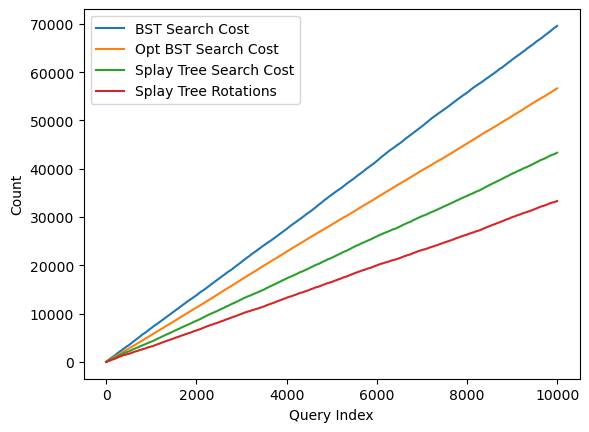

In [6]:
requests = generate_temporal_requests(100, 10000, p_repeat=0.5, dim=1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests)
plot_test(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

**p_repeat = 0.9**

Binary Search Tree Search Cost:  76968
Optimal Binary Search Tree Search Cost: 53534
Splay Tree Search Cost:  16528
Splay Tree Rotation Count:  6528


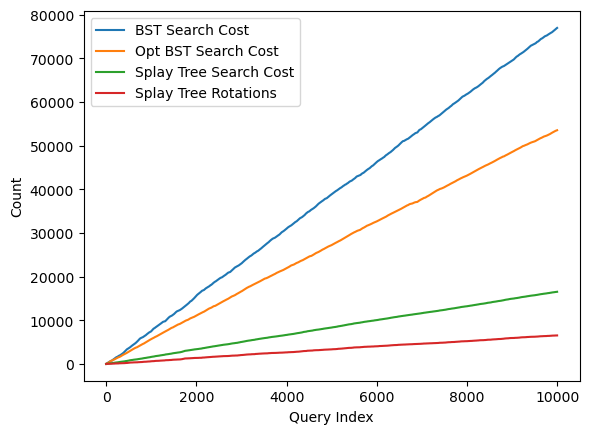

In [7]:
requests = generate_temporal_requests(100, 10000, p_repeat=0.9, dim=1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests)
plot_test(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)